# ENERGIZE NILM — Unstructured Pruning

Runs global **L1 unstructured pruning** over a list of sparsity levels.

For each sparsity level the notebook:
1. Reloads the trained baseline checkpoint
2. Applies `torch.nn.utils.prune.global_unstructured` (L1Unstructured)
3. Evaluates the pruned model (before fine-tuning)
4. Fine-tunes for `FINETUNE_EPOCHS` epochs (masks kept active → zeroed weights remain zero)
5. Removes pruning masks (bakes zeros into weights) and saves checkpoint
6. Evaluates the fine-tuned model

**Works with CNN, GRU, and TCN** — unlike structured pruning which cannot handle GRU/LSTM layers.

> Unstructured pruning does not change the model shape or tensor sizes,
> so MACs and parameter counts remain identical to the baseline.
> The compression metric is **sparsity %** (fraction of zero weights).

In [1]:
# ============================================================================
# COLAB SETUP — run this cell first
# ============================================================================
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch_pruning', 'openpyxl'])

    # =========================================================================
    DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks/ENERGIZE_COMPRESSION_FRAMEWORK FINAL'  # <-- EDIT THIS
    # =========================================================================

    import os
    from pathlib import Path
    project_root = Path(DRIVE_PROJECT_PATH)
    if not project_root.exists():
        raise FileNotFoundError(f'Project folder not found: {project_root}')
    os.chdir(project_root)
    sys.path.insert(0, str(project_root))
    print(f'Project root: {project_root}')
else:
    import os
    from pathlib import Path
    project_root = Path(os.getcwd()).parent
    sys.path.insert(0, str(project_root))
    print(f'Running locally. Project root: {project_root}')

Mounted at /content/drive
Project root: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_COMPRESSION_FRAMEWORK FINAL


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from tqdm import tqdm

from src_pytorch import (
    CNN_NILM, TCN_NILM, CNN_NILM_Seq2Seq,
    SimpleNILMDataLoader,
    set_seeds, get_device,
    compute_status, compute_metrics,
    get_model_config, get_appliance_params,
    get_model_stats, get_model_sparsity,
    apply_unstructured_pruning, remove_pruning_masks,
    get_prunable_parameters,
)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_608/832641574.py", line 8, in <cell line: 0>
    from src_pytorch import (
  File "/content/drive/MyDrive/Colab Notebooks/ENERGIZE_COMPRESSION_FRAMEWORK FINAL/src_pytorch/__init__.py", line 10, in <module>
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1132, in get_code
  File "<frozen importlib._bootstrap_external>", line 1190, in get_data
FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/ENERGIZE_COMPRESSION_FRAMEWORK FINAL/src_pytorc

## Configuration

Edit **only this cell**.

In [ ]:
# ============================================================================
# USER CONFIGURATION — edit only this cell
# ============================================================================

FINETUNE_EPOCHS = 1      # fine-tuning epochs after each pruning level
FINETUNE_LR     = 1e-4   # Adam learning rate for fine-tuning
SEED            = 42

# Experiments: list of dicts with model, appliance, and sparsity levels
# Sparsity = fraction of weights to zero (0.50 → 50% of weights become 0)
EXPERIMENTS = [
    {
        'model'           : 'cnn_seq2seq',
        'appliance'       : 'boiler',
        'sparsity_levels' : [0.50],
    },
    # Uncomment to add more experiments:
    # {'model': 'cnn',         'appliance': 'boiler',          'sparsity_levels': [0.25, 0.50, 0.75, 0.90, 0.95]},
    # {'model': 'cnn_seq2seq', 'appliance': 'boiler',          'sparsity_levels': [0.25, 0.50, 0.75, 0.90, 0.95]},
    # {'model': 'wavenet_tcn', 'appliance': 'washing_machine', 'sparsity_levels': [0.25, 0.50, 0.75, 0.90, 0.95]},
]

DATASET = 'plegma'
# ============================================================================

In [ ]:
# ============================================================================
# AUTO-DERIVED — do not edit
# ============================================================================
REPO_ROOT   = project_root
DATA_DIR   = Path('/content/drive/MyDrive/Colab Notebooks/ENERGIZE') / 'data' / 'processed' / 'plegma' / EXPERIMENTS[0]['appliance']
OUTPUTS_DIR = project_root / 'outputs'

set_seeds(SEED)
DEVICE = get_device()

print(f'Repo root : {REPO_ROOT}')
print(f'Data dir  : {DATA_DIR}')
print(f'Device    : {DEVICE}')

Seeds set to 42
Using GPU: NVIDIA A100-SXM4-80GB
GPU Memory: 85.09 GB
Repo root : /content/drive/MyDrive/Colab Notebooks/ENERGIZE_COMPRESSION_FRAMEWORK FINAL
Data dir  : /content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/boiler
Device    : cuda


## Helper Functions

In [ ]:
def build_model(model_name: str, cfg: dict, ckpt_path, device):
    """Instantiate and load a fresh model from a checkpoint."""
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(
            f'Checkpoint not found: {ckpt_path}\n'
            'Run 01_data_prep_training.ipynb first.'
        )
    window = cfg['input_window_length']
    if model_name == 'cnn':
        model = CNN_NILM(input_window_length=window)
    elif model_name == 'cnn_seq2seq':
        model = CNN_NILM_Seq2Seq(input_window_length=window)
    elif model_name == 'wavenet_tcn':
        model = TCN_NILM(
            input_window_length=window,
            depth=cfg.get('depth', 9),
            nb_filters=cfg.get('nb_filters'),
            dropout=cfg.get('dropout', 0.2),
            stacks=cfg.get('stacks', 1),
        )
    else:
        raise ValueError(f"Unknown model: {model_name}. Choose 'cnn', 'cnn_seq2seq', or 'wavenet_tcn'.")
    model.load_state_dict(torch.load(str(ckpt_path), map_location=device))
    return model.to(device).eval()


def evaluate(model, data_loader, model_name, app_params, cfg, device):
    """Run inference on the test split and return metrics + predictions."""
    from src_pytorch.evaluator import evaluate_model

    return evaluate_model(
        model=model,
        data_loader=data_loader,
        model_name=model_name,
        cutoff=app_params['cutoff'],
        threshold=app_params['threshold'],
        device=device,
        input_window_length=cfg['input_window_length'],
        min_on=app_params.get('min_on'),
        min_off=app_params.get('min_off'),
        min_committed_duration=app_params.get('min_committed_duration'),
    )


def finetune(model, data_loader, model_name, epochs, lr, device):
    """Fine-tune model in-place. Pruning masks (if present) stay active."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        n_batches  = 0
        for batch_x, batch_y in tqdm(data_loader.train, desc=f'  Epoch {epoch}/{epochs}'):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            if model_name == 'cnn' and batch_y.dim() == 1:
                batch_y = batch_y.unsqueeze(1)
            elif model_name in ('cnn_seq2seq', 'wavenet_tcn') and batch_y.dim() == 2:
                batch_y = batch_y.unsqueeze(-1)
            loss = loss_fn(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches  += 1
        print(f'  Epoch {epoch}/{epochs} — avg MSE: {total_loss / n_batches:.6f}')
    model.eval()


def save_predictions(output_dir, slug, gt, pred, gt_status, pred_status):
    pred_dir = output_dir / 'predictions'
    pred_dir.mkdir(parents=True, exist_ok=True)
    path = pred_dir / f'{slug}_preds.csv'
    np.savetxt(
        path,
        np.column_stack([gt, pred, gt_status.astype(int), pred_status.astype(int)]),
        delimiter=',',
        header='ground_truth_W,prediction_W,ground_truth_status,predicted_status',
        comments='', fmt=['%.4f', '%.4f', '%d', '%d'],
    )


def print_metrics(metrics, label=''):
    f1c  = metrics.get('f1_complex')
    prec = metrics.get('precision_complex')
    rec  = metrics.get('recall_complex')
    print(f'  {"-"*40}')
    if label:
        print(f'  {label}')
    print(f'  MAE            : {metrics["mae"]:.4f} W')
    if f1c is not None:
        print(f'  F1 Complex     : {f1c:.4f}')
        print(f'  Precision Cmplx: {prec:.4f}')
        print(f'  Recall Complex : {rec:.4f}')
    print(f'  Accuracy       : {metrics["accuracy"]:.4f}')
    print(f'  {"-"*40}')

## Define `run_experiment`

In [ ]:
def run_experiment(model_name: str, appliance_name: str, sparsity_levels: list):
    """
    Full unstructured pruning pipeline for one (model, appliance) pair.

    For each sparsity level:
      1. Reload baseline checkpoint
      2. Apply global L1 unstructured pruning
      3. Evaluate pruned (no finetune)
      4. Fine-tune (masks kept active during training)
      5. Remove masks → save checkpoint
      6. Evaluate fine-tuned

    Returns a dict with baseline and per-level results.
    """
    print(f'\n{"#"*70}')
    print(f'  EXPERIMENT: {model_name.upper()} | {appliance_name.upper()}')
    print(f'{"#"*70}')

    cfg        = get_model_config(model_name)
    app_params = get_appliance_params(DATASET, appliance_name)
    output_dir = OUTPUTS_DIR / f'{model_name}_{appliance_name}'
    models_dir = output_dir / 'models'
    models_dir.mkdir(parents=True, exist_ok=True)

    ckpt_path = output_dir / 'checkpoint' / 'model.pt'
    label     = f'{model_name}_{appliance_name}'

    # ── Data loader ──────────────────────────────────────────────────────────
    data_loader = SimpleNILMDataLoader(
        data_dir=str(DATA_DIR),
        model_name=model_name,
        batch_size=cfg['batch_size'],
        input_window_length=cfg['input_window_length'],
        train=True,
        num_workers=0,
    )

    # ── Baseline evaluation ───────────────────────────────────────────────────
    print(f'\n{"-"*60}')
    print(f'  Baseline evaluation')
    print(f'{"-"*60}')
    base_model = build_model(model_name, cfg, ckpt_path, DEVICE)

    dummy    = torch.randn(1, cfg['input_window_length']).to(DEVICE)
    b_params, b_macs, b_mb = get_model_stats(base_model, dummy)

    print(f'  Params: {b_params:,}  |  MACs: {b_macs:,}  |  Size: {b_mb:.3f} MB')
    print(f'  Prunable parameters:')
    for m, n in get_prunable_parameters(base_model):
        w = getattr(m, n)
        print(f'    {type(m).__name__}.{n:30s} {list(w.shape)}')

    base_metrics, b_gt, b_pred, b_gt_s, b_pred_s = evaluate(
        base_model, data_loader, model_name, app_params, cfg, DEVICE
    )
    print_metrics(base_metrics, label='Baseline')
    save_predictions(output_dir, f'{label}_unstructured_baseline', b_gt, b_pred, b_gt_s, b_pred_s)

    all_results = []

    # ── Pruning loop ──────────────────────────────────────────────────────────
    for sparsity in sparsity_levels:
        pct = int(sparsity * 100)
        print(f'\n{"="*60}')
        print(f'  Sparsity {pct}%  |  {model_name.upper()}  |  {appliance_name}')
        print(f'{"="*60}')

        # Reload fresh baseline weights
        model = build_model(model_name, cfg, ckpt_path, DEVICE)

        # ── 1. Apply unstructured pruning ────────────────────────────────────
        model = apply_unstructured_pruning(model, amount=sparsity)
        actual_sparsity = get_model_sparsity(model)

        # ── 2. Evaluate pruned (no finetune) ─────────────────────────────────
        pruned_metrics, p_gt, p_pred, p_gt_s, p_pred_s = evaluate(
            model, data_loader, model_name, app_params, cfg, DEVICE
        )
        print_metrics(pruned_metrics, label=f'Pruned {pct}% (no finetune)')
        save_predictions(output_dir, f'{label}_unstructured_pruned_{pct}pct', p_gt, p_pred, p_gt_s, p_pred_s)

        # ── 3. Fine-tune (masks kept active) ─────────────────────────────────
        print(f'\n  Fine-tuning {FINETUNE_EPOCHS} epochs  |  LR={FINETUNE_LR}')
        finetune(model, data_loader, model_name, FINETUNE_EPOCHS, FINETUNE_LR, DEVICE)

        # ── 4. Remove masks → save checkpoint ────────────────────────────────
        remove_pruning_masks(model)
        ckpt_ft = models_dir / f'{label}_unstructured_{pct}pct_finetuned.pt'
        torch.save(model.state_dict(), ckpt_ft)
        print(f'  Checkpoint saved: {ckpt_ft.name}')

        # ── 5. Evaluate fine-tuned ────────────────────────────────────────────
        ft_metrics, ft_gt, ft_pred, ft_gt_s, ft_pred_s = evaluate(
            model, data_loader, model_name, app_params, cfg, DEVICE
        )
        print_metrics(ft_metrics, label=f'Pruned {pct}% + Finetuned {FINETUNE_EPOCHS}ep')
        save_predictions(output_dir, f'{label}_unstructured_{pct}pct_finetuned', ft_gt, ft_pred, ft_gt_s, ft_pred_s)

        all_results.append({
            'sparsity_target'  : pct,
            'sparsity_actual'  : round(actual_sparsity * 100, 2),
            'params'           : b_params,
            'macs'             : b_macs,
            'mb'               : b_mb,
            'pruned_metrics'   : pruned_metrics,
            'finetuned_metrics': ft_metrics,
        })

    return {
        'model'           : model_name,
        'appliance'       : appliance_name,
        'baseline_metrics': base_metrics,
        'baseline_params' : b_params,
        'baseline_macs'   : b_macs,
        'baseline_mb'     : b_mb,
        'all_results'     : all_results,
        'output_dir'      : output_dir,
    }

## Run All Experiments

In [ ]:
all_experiments = []

for _exp in EXPERIMENTS:
    _result = run_experiment(
        model_name     = _exp['model'],
        appliance_name = _exp['appliance'],
        sparsity_levels= _exp['sparsity_levels'],
    )
    all_experiments.append(_result)

print(f'\n{"#"*70}')
print(f'  All {len(EXPERIMENTS)} experiment(s) complete.')
print(f'{"#"*70}')


######################################################################
  EXPERIMENT: CNN_SEQ2SEQ | BOILER
######################################################################

------------------------------------------------------------
  Baseline evaluation
------------------------------------------------------------
  Params: 14,168,899  |  MACs: 24,484,743.0  |  Size: 54.050 MB
  Prunable parameters:
    Conv1d.weight                         [30, 1, 10]
    Conv1d.weight                         [30, 30, 8]
    Conv1d.weight                         [40, 30, 6]
    Conv1d.weight                         [50, 40, 5]
    Conv1d.weight                         [50, 50, 5]
    Linear.weight                         [1024, 13500]
    Linear.weight                         [299, 1024]


Inference: 100%|██████████| 11/11 [00:00<00:00, 87.61it/s]


  ----------------------------------------
  Baseline
  MAE            : 7.9734 W
  F1 Complex     : 0.9562
  Precision Cmplx: 0.9298
  Recall Complex : 0.9843
  Accuracy       : 0.9984
  ----------------------------------------

  Sparsity 50%  |  CNN_SEQ2SEQ  |  boiler
Unstructured pruning applied — amount: 50%
Global sparsity : 50.0%  (7,083,688 / 14,167,376 weights zeroed)


Inference: 100%|██████████| 11/11 [00:00<00:00, 84.33it/s]


  ----------------------------------------
  Pruned 50% (no finetune)
  MAE            : 12.7558 W
  F1 Complex     : 0.9598
  Precision Cmplx: 0.9366
  Recall Complex : 0.9842
  Accuracy       : 0.9985
  ----------------------------------------

  Fine-tuning 1 epochs  |  LR=0.0001


  Epoch 1/1: 100%|██████████| 46335/46335 [13:48<00:00, 55.93it/s]


  Epoch 1/1 — avg MSE: 0.000360
  Checkpoint saved: cnn_seq2seq_boiler_unstructured_50pct_finetuned.pt


Inference: 100%|██████████| 11/11 [00:00<00:00, 86.32it/s]


  ----------------------------------------
  Pruned 50% + Finetuned 1ep
  MAE            : 8.4721 W
  F1 Complex     : 0.9410
  Precision Cmplx: 0.9027
  Recall Complex : 0.9827
  Accuracy       : 0.9978
  ----------------------------------------

######################################################################
  All 1 experiment(s) complete.
######################################################################


## Summary Tables & Save Results

In [ ]:
def _v(d, k, fmt='.4f'):
    v = d.get(k)
    return f'{v:{fmt}}' if v is not None else '—'


for exp in all_experiments:
    m_name  = exp['model'].upper()
    app     = exp['appliance'].replace('_', ' ').title()
    bm      = exp['baseline_metrics']

    print(f'\n{"="*80}')
    print(f'  {m_name}  |  {app}  —  Unstructured Pruning Results')
    print(f'{"="*80}')

    rows = []

    # Baseline row
    rows.append({
        'Stage'             : f'{m_name} Baseline',
        'Sparsity_%'        : 0,
        'Params'            : exp['baseline_params'],
        'MACs'              : exp['baseline_macs'],
        'MB'                : exp['baseline_mb'],
        'MAE'               : round(bm['mae'],                          4),
        'F1_Complex'        : round(bm['f1_complex'],        4) if bm.get('f1_complex')        is not None else None,
        'Precision_Complex' : round(bm['precision_complex'], 4) if bm.get('precision_complex') is not None else None,
        'Recall_Complex'    : round(bm['recall_complex'],    4) if bm.get('recall_complex')    is not None else None,
        'Accuracy'          : round(bm['accuracy'],                     4),
        'GT_Energy_Wh'      : round(bm['total_gt_energy_wh'],           2),
        'Pred_Energy_Wh'    : round(bm['total_pred_energy_wh'],         2),
    })

    for r in exp['all_results']:
        pct = r['sparsity_target']
        for stage_key, stage_label in [
            ('pruned_metrics',    f'{m_name} Pruned {pct}%'),
            ('finetuned_metrics', f'{m_name} Pruned {pct}% + Finetuned {FINETUNE_EPOCHS}ep'),
        ]:
            sm = r[stage_key]
            rows.append({
                'Stage'             : stage_label,
                'Sparsity_%'        : r['sparsity_actual'],
                'Params'            : r['params'],
                'MACs'              : r['macs'],
                'MB'                : r['mb'],
                'MAE'               : round(sm['mae'],                          4),
                'F1_Complex'        : round(sm['f1_complex'],        4) if sm.get('f1_complex')        is not None else None,
                'Precision_Complex' : round(sm['precision_complex'], 4) if sm.get('precision_complex') is not None else None,
                'Recall_Complex'    : round(sm['recall_complex'],    4) if sm.get('recall_complex')    is not None else None,
                'Accuracy'          : round(sm['accuracy'],                     4),
                'GT_Energy_Wh'      : round(sm['total_gt_energy_wh'],           2),
                'Pred_Energy_Wh'    : round(sm['total_pred_energy_wh'],         2),
            })

    df = pd.DataFrame(rows)
    display(df)

    # ── Save to Excel ─────────────────────────────────────────────────────────
    xlsx_path = exp['output_dir'] / f'{exp["model"]}_{exp["appliance"]}_unstructured_results.xlsx'
    df.to_excel(xlsx_path, index=False)
    print(f'  Results saved -> {xlsx_path.relative_to(REPO_ROOT)}')


  WAVENET_TCN  |  Boiler  —  Unstructured Pruning Results


,Stage,Sparsity_%,Params,MACs,MB,MAE,F1_Complex,Precision_Complex,Recall_Complex,Accuracy,GT_Energy_Wh,Pred_Energy_Wh
0,WAVENET_TCN Baseline,0.0,5794433,3.776068e+09,22.104,10.0493,0.9331,0.9044,0.9637,0.9972,22142.48,22857.900391
1,WAVENET_TCN Pruned 50%,50.0,5794433,3.776068e+09,22.104,49.0059,0.0000,0.0000,0.0000,0.9829,22142.48,0.000000
2,WAVENET_TCN Pruned 50% + Finetuned 1ep,50.0,5794433,3.776068e+09,22.104,10.6719,0.9328,0.8873,0.9831,0.9965,22142.48,24095.130859


  Results saved -> outputs/wavenet_tcn_boiler/wavenet_tcn_boiler_unstructured_results.xlsx


## Plot — F1 Complex vs Sparsity

Figure saved -> outputs/wavenet_tcn_boiler/figures/wavenet_tcn_boiler_unstructured_f1complex_vs_sparsity.png


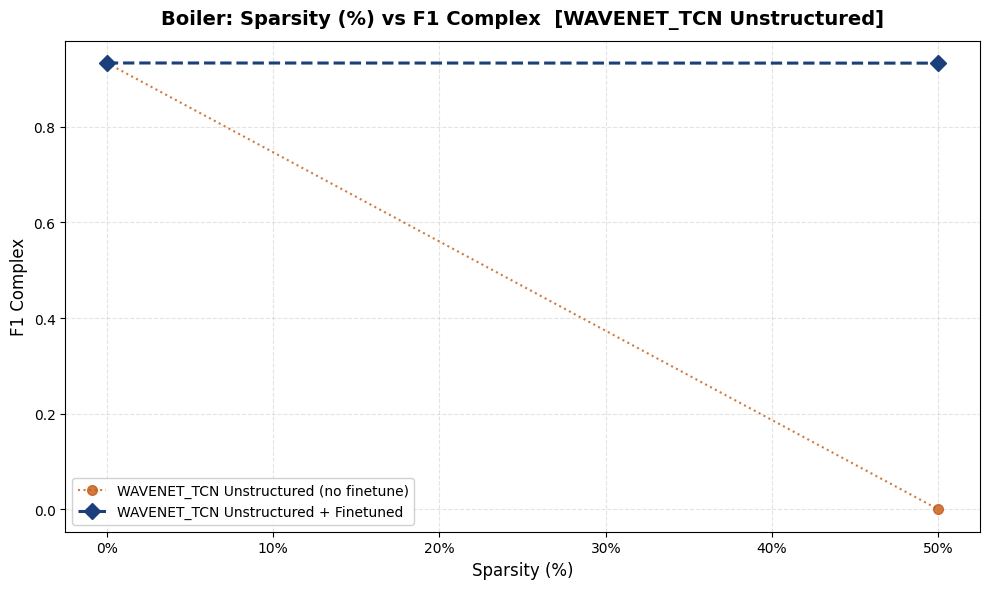

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

C_NAVY   = '#1B3F7A'
C_ORANGE = '#C55A11'

for exp in all_experiments:
    m_name  = exp['model'].upper()
    app     = exp['appliance'].replace('_', ' ').title()
    bm      = exp['baseline_metrics']
    results = exp['all_results']

    sparsity_pts = [0] + [r['sparsity_actual'] for r in results]
    f1_pruned    = [bm.get('f1_complex', 0)] + [
        r['pruned_metrics'].get('f1_complex', 0) for r in results
    ]
    f1_finetuned = [bm.get('f1_complex', 0)] + [
        r['finetuned_metrics'].get('f1_complex', 0) for r in results
    ]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(sparsity_pts, f1_pruned,
            color=C_ORANGE, marker='o', linewidth=1.5, markersize=7,
            linestyle=':', alpha=0.8,
            label=f'{m_name} Unstructured (no finetune)')

    ax.plot(sparsity_pts, f1_finetuned,
            color=C_NAVY, marker='D', linewidth=2.2, markersize=8,
            linestyle='--',
            label=f'{m_name} Unstructured + Finetuned')

    ax.set_xlabel('Sparsity (%)', fontsize=12)
    ax.set_ylabel('F1 Complex', fontsize=12)
    ax.set_title(
        f'{app}: Sparsity (%) vs F1 Complex  [{m_name} Unstructured]',
        fontsize=14, fontweight='bold', pad=12
    )
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(fontsize=10, loc='lower left', framealpha=0.9)
    plt.tight_layout()

    fig_dir  = exp['output_dir'] / 'figures'
    fig_dir.mkdir(exist_ok=True)
    fig_path = fig_dir / f'{exp["model"]}_{exp["appliance"]}_unstructured_f1complex_vs_sparsity.png'
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Figure saved -> {fig_path.relative_to(REPO_ROOT)}')
    plt.show()